<a id='notebook-top'></a>

# Photospheric Magnetic Field beneath Chromospheric Fibrils
---
This notebook shows the photospheric magnetograms beneath the chromospheric fibrils, inverted from Hinode/SOT-SP data. Additionally, the comparison to other magnetograms from SDO/HMI, DKIST/ViSP, and PHI/HRI is also included.  

Note: The internal hyperlink only works on [GitHub Pages](https://yjzhu-solar.github.io/DKIST_SolO_Fibril/ipynb_html/app_magnetograms.html) or [nbviewer](https://nbviewer.org/github/yjzhu-solar/DKIST_SolO_Fibril/blob/master/ipynb/ms_plot/app_magnetograms.ipynb). Do not click when viewing the notebook on GitHub.

## Import libraries and plotting configurations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import sunpy 
import sunpy.map
from sunpy.coordinates import propagate_with_solar_surface
import astropy
from astropy.io import fits, ascii
from astropy.visualization import ImageNormalize, AsinhStretch
import astropy.units as u
from sun_blinker import ImageBlinker, SunBlinker
import dkist
from fancy_colorbar import plot_colorbar
from sunkit_image import coalignment
from ndcube import NDCube
from astropy.wcs import WCS
import h5py 
import dask.array as da
from astropy.time import Time
from IPython.display import HTML, display

In [2]:
ms_style_dict = {'text.usetex': True, 'font.family': 'serif', 'axes.linewidth': 1.2,
                 'xtick.major.width': 1.2, 'xtick.major.size': 4,
                 'ytick.major.width': 1.2, 'ytick.major.size': 4,
                 'xtick.minor.width': 1.2, 'xtick.minor.size': 2,
                 'ytick.minor.width': 1.2, 'ytick.minor.size': 2,
                 'xtick.direction': 'in', 'ytick.direction': 'in',
                 'text.latex.preamble': r'\usepackage[T1]{fontenc}'
                 r'\usepackage{amsmath}' r'\usepackage{siunitx}'
                 r'\sisetup{detect-all=True}' r'\usepackage{fixltx2e}'}

## Load the data

### DKIST/ViSP magnetogram

In [3]:
dkist_fitv_tom_btot_map_shift = sunpy.map.Map("../../data/pid_1_123/BKEWK/dkist_fitv_tom_btot_map_shift.fits")
dkist_ftiv_tom_theta_map_shifted_masked = sunpy.map.Map("../../data/pid_1_123/BKEWK/dkist_fitv_tom_theta_map_shifted_masked.fits")
dkist_br_map = sunpy.map.Map(dkist_fitv_tom_btot_map_shift.data * np.cos(np.deg2rad(dkist_ftiv_tom_theta_map_shifted_masked.data)),
                             dkist_fitv_tom_btot_map_shift.meta)
dkist_br_map.plot_settings['aspect'] = dkist_br_map.scale.axis2/dkist_br_map.scale.axis1

### HMI VFISV & SuperSynthIA

In [4]:
hmi_supersynthia_br_file = "../../data/hmi/supersynthia/hmi.SuperSynthIA.20221024_191200_TAI.Br.fits"

with fits.open(hmi_supersynthia_br_file) as hdul:
    hmi_ss_br = hdul[1].data.copy()
    hmi_ss_header = hdul[0].header.copy()

hmi_supersynthia_bp_file = "../../data/hmi/supersynthia/hmi.SuperSynthIA.20221024_191200_TAI.Bp.fits"

with fits.open(hmi_supersynthia_bp_file) as hdul:
    hmi_ss_bp = hdul[1].data.copy()

hmi_supersynthia_bt_file = "../../data/hmi/supersynthia/hmi.SuperSynthIA.20221024_191200_TAI.Bt.fits"

with fits.open(hmi_supersynthia_bt_file) as hdul:
    hmi_ss_bt = hdul[1].data.copy()

hmi_supersynthia_binc_file = "../../data/hmi/supersynthia/hmi.SuperSynthIA.20221024_191200_TAI.Field_Inclination.fits"

with fits.open(hmi_supersynthia_binc_file) as hdul:
    hmi_ss_binc = hdul[1].data.copy()

hmi_ss_blos = np.sqrt(hmi_ss_br**2 + hmi_ss_bp**2 + hmi_ss_bt**2)*np.cos(np.deg2rad(hmi_ss_binc))



In [5]:
hmi_m_720s_map = sunpy.map.Map("../../data/hmi/supersynthia/hmi.M_720s.20221024_191200_TAI.3.magnetogram.fits")

In [6]:
hmi_ss_map = sunpy.map.Map(hmi_ss_blos, hmi_m_720s_map.wcs)

In [7]:
# hmi_sharp_bmag_map = sunpy.map.Map("../../data/pid_1_123_aux/HMI/hmi.sharp_720s.8718.20221024_191200_TAI.magnetogram.fits")
# hmi_sharp_binc_map = sunpy.map.Map("../../data/pid_1_123_aux/HMI/hmi.sharp_720s.8718.20221024_191200_TAI.inclination.fits")
# hmi_sharp_blos_map = sunpy.map.Map(hmi_sharp_bmag_map.data * np.cos(np.deg2rad(hmi_sharp_binc_map.data)), hmi_sharp_bmag_map.meta)
hmi_sharp_blos_map = sunpy.map.Map("../../data/pid_1_123_aux/HMI/hmi.sharp_720s.8718.20221024_191200_TAI.magnetogram.fits")

### DKIST/VBI data

In [8]:
file_Hbeta_pr = h5py.File("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_pr.hdf5")
Hbeta_pr_set = file_Hbeta_pr["vbi_img"]
Hbeta_pr_da = da.from_array(Hbeta_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Hbeta_date_obs = Time(ascii.read("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_date_avg.txt")["DATE-AVG"])

file_Gband_pr = h5py.File("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/plot_ready/Gband_AEZDV_pr.hdf5")
Gband_pr_set = file_Gband_pr["vbi_img"]
Gband_pr_da = da.from_array(Gband_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Gband_date_obs = Time(ascii.read("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/plot_ready/Gband_AEZDV_date_avg.txt")["DATE-AVG"])

dkist_vbi_target_header = fits.getheader("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)

dkist_vbi_target_data = np.zeros((4096,4096))

dkist_vbi_target_cube = NDCube(dkist_vbi_target_data,WCS(dkist_vbi_target_header, naxis=2))
dkist_vbi_target_cube_crop = dkist_vbi_target_cube[128:-128,128:-128]
dkist_vbi_target_cube_crop_rebin = dkist_vbi_target_cube_crop.rebin((16,16))
dkist_vbi_target_cube_crop_rebin_4 = dkist_vbi_target_cube_crop.rebin((4,4))

Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


### Hinode/SOT-SP magnetogram

In [9]:
sotsp_blos_map = sunpy.map.Map("../../data/pid_1_123_aux/SOTSP/sotsp_blos_warp_to_hmi.fits")

### Solar Orbiter PHI/HRI magnetogram

In [10]:
hrt_map = sunpy.map.Map("/cluster/home/zhuyin/Solar/extrapolate_schmidt64/data/phi_los_map_shifted_for_pore.fits")

### Reproject the magnetograms to the same FOV

In [11]:
def repro_higherlevel_wcs(map, target_wcs, algorithm="adaptive"):
    cube = NDCube(map.data, map.wcs)
    cube_repro = cube.reproject_to(target_wcs, algorithm=algorithm)

    return cube_repro

In [12]:
with propagate_with_solar_surface():
    dkist_br_map_to_vbi = repro_higherlevel_wcs(dkist_br_map, dkist_vbi_target_cube_crop_rebin_4.wcs, algorithm="exact")
    hmi_ss_map_to_vbi = repro_higherlevel_wcs(hmi_ss_map, dkist_vbi_target_cube_crop_rebin.wcs, algorithm="exact")
    sotsp_blos_map_to_vbi = repro_higherlevel_wcs(sotsp_blos_map, dkist_vbi_target_cube_crop_rebin_4.wcs, algorithm="exact")
    hrt_map_to_vbi = repro_higherlevel_wcs(hrt_map, dkist_vbi_target_cube_crop_rebin.wcs, algorithm="exact")
    hmi_sharp_map_to_vbi = repro_higherlevel_wcs(hmi_sharp_blos_map, dkist_vbi_target_cube_crop_rebin.wcs, algorithm="exact")

/cluster/home/zhuyin/sunpy_env/lib/python3.11/site-packages/reproject/common.py:142: UserWarning: The reproject_exact function currently has precision issues with images that have resolutions below ~0.05 arcsec, so the results may not be accurate.
  return reproject_func(


In [13]:
Hbeta_index = 98

vbi_hbeta_example = Hbeta_pr_da[Hbeta_index,:,:].compute()

In [14]:
vbi_hbeta_example.shape

(3840, 3840)

In [15]:
sotsp_blos_map_to_vbi.data.shape

(960, 960)

## Figure 3
---
Photospheric magnetic field below the fibrils. (a) VBI H$β$ image with SOT/SP $fB_{\rm LOS}$ contours at $>50$ G (red) and $<-50$ G (blue); (b) SOT/SP LOS magnetogram $fB_{\rm LOS}$.

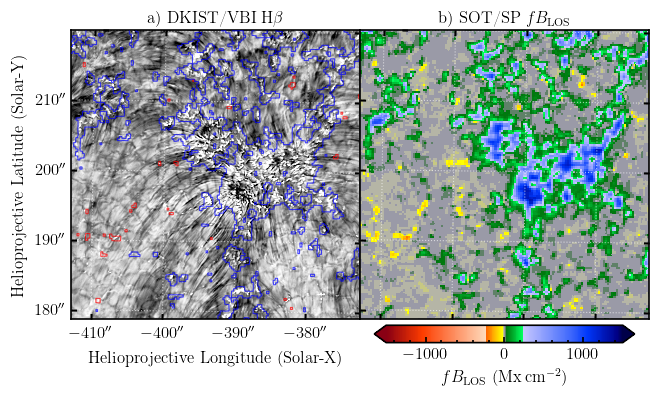

In [16]:
plt.close("all")

display(HTML('<a href="#notebook-top">Go to top</a>'))
display(HTML('<a id="figure-2"></a>'))

with plt.rc_context(ms_style_dict):
    fig = plt.figure(figsize=(6.5,4))
    fig.subplots_adjust(left=0.1, bottom=0.12, top=0.85, right=0.99, wspace=0, hspace=0)

    ax1 = fig.add_subplot(1,2,1,projection=dkist_vbi_target_cube_crop.wcs)
    ax2 = fig.add_subplot(1,2,2,projection=dkist_vbi_target_cube_crop_rebin_4.wcs)

    im_vbi = ax1.imshow(vbi_hbeta_example, cmap="Greys_r",
                norm=ImageNormalize(vmin=-0.2, vmax=1.1,
                # stretch=AsinhStretch(0.6)
                ),
                interpolation="none",
                origin="lower", rasterized=True)
    

    ax1.contour(sotsp_blos_map_to_vbi.data, levels=[-50,50],
                colors=["red", "blue"], linewidths=0.8,
                extent=im_vbi.get_extent(), origin="lower", alpha=0.7)

    im2 = ax2.imshow(sotsp_blos_map_to_vbi.data, cmap="hmimag",
                norm=ImageNormalize(vmin=-1500, vmax=1500),
                interpolation="none",
                origin="lower", rasterized=True)

    clb, clb_ax = plot_colorbar(im2, ax2, bbox_to_anchor=[0.05,-0.08,0.9,0.06], fontsize=12, extend="both",
    orientation="horizontal")
    clb_ax.set_xlabel(r"$f B_{\rm LOS}$ (Mx\,cm$^{-2}$)", fontsize=12)
    # clb_ax.xaxis.set_label_position("top")
    # clb_ax.xaxis.set_ticks_position("top")

    ax1.set_title(r'a) DKIST/VBI H$\beta$', color='black',
            fontsize=12)

    ax2.set_title(r'b) SOT/SP $fB_{\rm LOS}$', color='black',
                fontsize=12)

    for ax_ in (ax1,ax2,clb_ax):
        ax_.tick_params(labelsize=12)

    ax2.coords[0].axislabels.set_visible(False)
    ax2.coords[1].axislabels.set_visible(False)
    ax2.coords[0].set_ticklabel_visible(False)
    ax2.coords[1].set_ticklabel_visible(False)
    ax1.coords[0].set_axislabel("Helioprojective Longitude (Solar-X)", fontsize=12)
    ax1.coords[1].set_axislabel("Helioprojective Latitude (Solar-Y)", fontsize=12)

    for ax_ in (ax1,ax2):
        ax_.coords.grid(True,color="white",lw=0.8, alpha=0.6, ls=":")

    fig.savefig("../../figs/ms_figure/sotsp_magnetogram.pdf", bbox_inches="tight", dpi=300)
    fig.savefig("../../figs/ms_figure_png/sotsp_magnetogram.png", bbox_inches="tight", dpi=300)

    plt.show()

## Figure B.1
---
Comparison of LOS photospheric magnetic flux density, $fB_{\rm LOS}$, measured by different instruments: (a) VBI H$\beta$ image with SOT/SP $fB_{\rm LOS}$ contours at $>50$ G (red) and $<-50$ G (blue); (b) DKIST/ViSP; (c) SOT/SP; (d) HMI inverted with SuperSynthIA; (e) HMI SHARP inverted with VFISV; (f) Reprojected PHI/HRT. The magnetic filling factor $f$ is assumed to be unity for ViSP, HMI SHARP, and PHI/HRT.

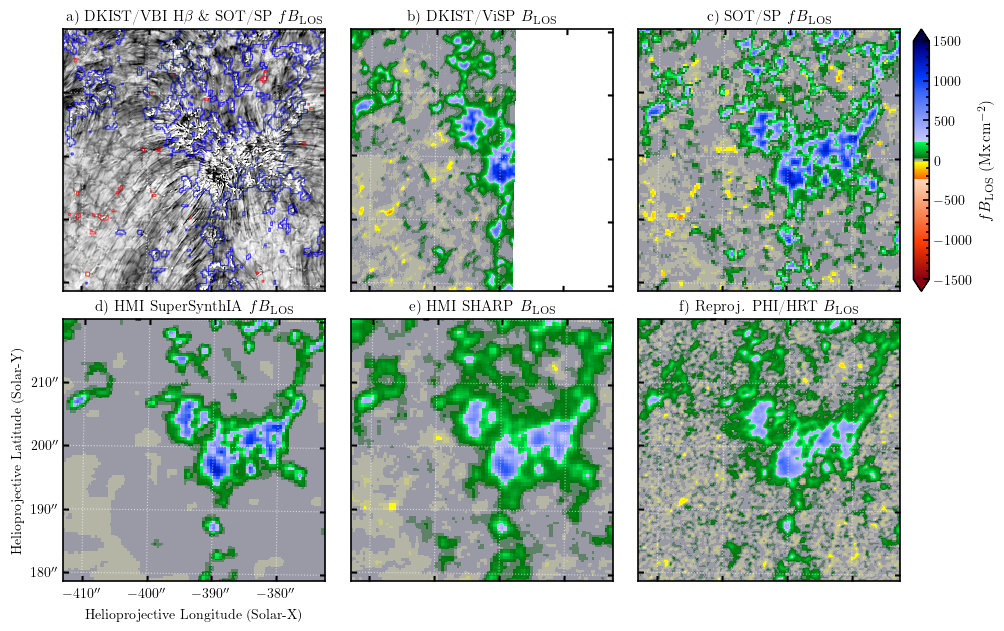

In [17]:
plt.close("all")

display(HTML('<a href="#notebook-top">Go to top</a>'))
display(HTML('<a id="figure-b1"></a>'))

with plt.rc_context(ms_style_dict):
    fig = plt.figure(figsize=(10,6.2),layout='constrained')

    ax1 = fig.add_subplot(2,3,1,projection=dkist_vbi_target_cube_crop.wcs)
    ax2 = fig.add_subplot(2,3,2,projection=dkist_vbi_target_cube_crop_rebin_4.wcs)
    ax3 = fig.add_subplot(2,3,3,projection=dkist_vbi_target_cube_crop_rebin_4.wcs)
    ax4 = fig.add_subplot(2,3,4,projection=dkist_vbi_target_cube_crop_rebin.wcs)
    ax5 = fig.add_subplot(2,3,5,projection=dkist_vbi_target_cube_crop_rebin.wcs)
    ax6 = fig.add_subplot(2,3,6,projection=dkist_vbi_target_cube_crop_rebin.wcs)

    im_vbi = ax1.imshow(vbi_hbeta_example, cmap="Greys_r",
                norm=ImageNormalize(vmin=-0.2, vmax=1.1,
                # stretch=AsinhStretch(0.6)
                ),
                interpolation="none",
                origin="lower", rasterized=True)
    

    ax1.contour(sotsp_blos_map_to_vbi.data, levels=[-50,50],
                colors=["red", "blue"], linewidths=0.8,
                extent=im_vbi.get_extent(), origin="lower", alpha=0.7)

    im2 = ax2.imshow(dkist_br_map_to_vbi.data, cmap="hmimag",
                norm=ImageNormalize(vmin=-1500, vmax=1500),
                interpolation="none",
                origin="lower", rasterized=True)

    ax3.imshow(sotsp_blos_map_to_vbi.data, cmap="hmimag",
                norm=ImageNormalize(vmin=-1500, vmax=1500),
                interpolation="none",
                origin="lower", rasterized=True)

    ax4.imshow(hmi_ss_map_to_vbi.data, cmap="hmimag",
                norm=ImageNormalize(vmin=-1500, vmax=1500),
                interpolation="none",
                origin="lower", rasterized=True)

    ax5.imshow(hmi_sharp_map_to_vbi.data, cmap="hmimag",
                norm=ImageNormalize(vmin=-1500, vmax=1500),
                interpolation="none",
                origin="lower", rasterized=True)

    ax6.imshow(hrt_map_to_vbi.data, cmap="hmimag",
                norm=ImageNormalize(vmin=-1500, vmax=1500),
                interpolation="none",
                origin="lower", rasterized=True)

    # hmi_ss_map_to_vbi.plot(axes=ax4, norm=ImageNormalize(vmin=-1500, vmax=1500), cmap='hmimag', title=None)
    # sotsp_br_warp_map_to_vbi.plot(axes=ax5, norm=ImageNormalize(vmin=-1500, vmax=1500), cmap='hmimag', title=None)
    # hrt_blos_map_to_vbi.plot(axes=ax6, norm=ImageNormalize(vmin=-1500, vmax=1500), cmap='hmimag', title=None)

    clb, clb_ax = plot_colorbar(im2, ax3, bbox_to_anchor=[1.05,0,0.06,1], fontsize=10, extend="both")
    clb_ax.set_ylabel(r"$f B_{\rm LOS}$ (Mx\,cm$^{-2}$)", fontsize=11)

    ax1.set_title(r'a) DKIST/VBI H$\beta$ \& SOT/SP $fB_{\rm LOS}$', color='black',
                fontsize=11)

    ax2.set_title(r'b) DKIST/ViSP $B_{\rm LOS}$', color='black',
                fontsize=11)
    
    ax3.set_title(r'c) SOT/SP $fB_{\rm LOS}$', color='black',
                fontsize=11)

    ax4.set_title(r'd) HMI SuperSynthIA $fB_{\rm LOS}$', color='black',
                fontsize=11)

    ax5.set_title(r'e) HMI SHARP $B_{\rm LOS}$', color='black',
                fontsize=11)

    ax6.set_title(r'f) Reproj. PHI/HRT $B_{\rm LOS}$', color='black',
                fontsize=11)

    for ax_ in (ax1,ax2,ax3,ax5,ax6):
        ax_.coords[0].axislabels.set_visible(False)
        ax_.coords[1].axislabels.set_visible(False)
        ax_.coords[0].set_ticklabel_visible(False)
        ax_.coords[1].set_ticklabel_visible(False)

    for ax_ in (ax1,ax2,ax3,ax4,ax5,ax6):
        ax_.coords.grid(True,color="white",lw=0.8, alpha=0.6, ls=":")

    ax4.set_xlabel("Helioprojective Longitude (Solar-X)")
    ax4.set_ylabel("Helioprojective Latitude (Solar-Y)")

    fig.savefig("../../figs/ms_figure/app_magnetogram_compare.pdf", bbox_inches="tight", dpi=150)
    fig.savefig("../../figs/ms_figure_png/app_magnetogram_compare.png", bbox_inches="tight", dpi=150)
    plt.show()




In [18]:
# a dark mode style
dm_fc = "#F3F4F3"
dm_bg = "#2D2F34"
ms_dm_style_dict = {'text.usetex': True, 'font.family': 'serif',
                    'font.serif': ['Computer Modern Roman'], 'axes.linewidth': 1.2,
                    'xtick.major.width': 1.2, 'xtick.major.size': 4,
                    'ytick.major.width': 1.2, 'ytick.major.size': 4,
                    'xtick.minor.width': 1.2, 'xtick.minor.size': 2,
                    'ytick.minor.width': 1.2, 'ytick.minor.size': 2,
                    'xtick.direction': 'in', 'ytick.direction': 'in',
                    'text.latex.preamble': r'\usepackage[T1]{fontenc}'
                    r'\usepackage{amsmath}' r'\usepackage{siunitx}'
                    r'\sisetup{detect-all=True}' r'\usepackage{fixltx2e}',
                    'lines.color': dm_fc, 'patch.edgecolor': dm_fc,
                    'text.color': dm_fc, 'axes.facecolor': dm_bg,
                    'axes.edgecolor': dm_fc, 'axes.labelcolor': dm_fc,
                    'axes.prop_cycle': plt.cycler(color=['#8dd3c7', '#feffb3', '#bfbbd9',
                    '#fa8174', '#81b1d2', '#fdb462', '#b3de69', '#bc82bd', '#ccebc4', '#ffed6f']),
                    'xtick.color': dm_fc, 'ytick.color': dm_fc,
                    'grid.color': dm_fc,
                    # 'figure.facecolor': dm_bg, 'figure.edgecolor': dm_bg,
                    # 'savefig.facecolor': dm_bg, 'savefig.edgecolor': dm_bg,
                    'figure.facecolor': "none", 'figure.edgecolor': "none",
                    'savefig.facecolor': "none", 'savefig.edgecolor': "none", 'savefig.transparent': True,
                    'axes.facecolor': "none", #'axes.edgecolor': "none",
                    'boxplot.boxprops.color': dm_fc,
                    'boxplot.capprops.color': dm_fc,
                    'boxplot.whiskerprops.color': dm_fc,
                    'boxplot.flierprops.color': dm_fc,
                    'boxplot.flierprops.markeredgecolor': dm_fc,} 

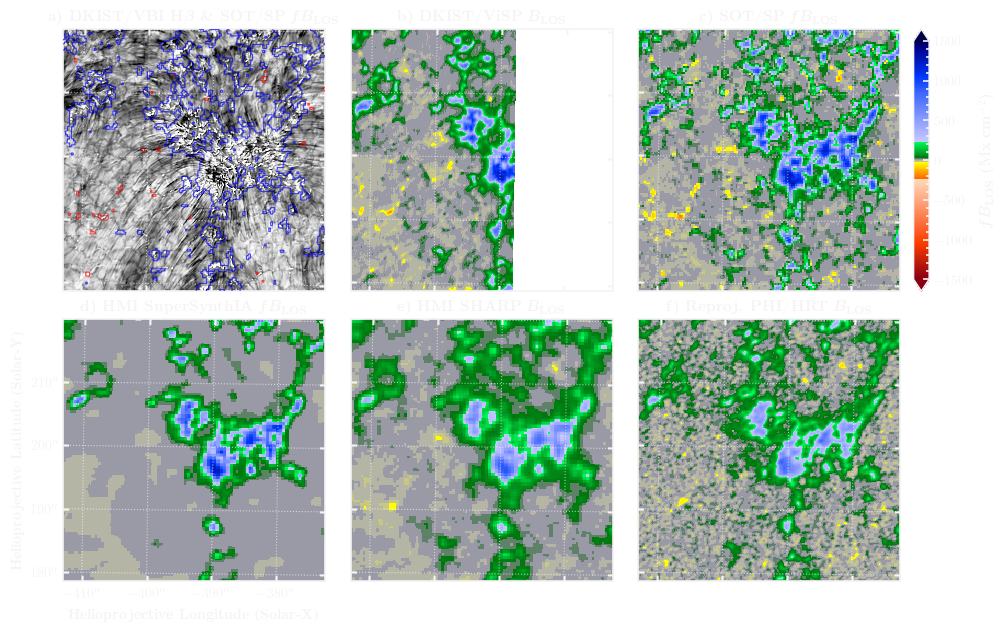

In [19]:
plt.close("all")

display(HTML('<a href="#notebook-top">Go to top</a>'))

with plt.rc_context(ms_dm_style_dict):
    fig = plt.figure(figsize=(10,6.2),layout='constrained')

    ax1 = fig.add_subplot(2,3,1,projection=dkist_vbi_target_cube_crop.wcs)
    ax2 = fig.add_subplot(2,3,2,projection=dkist_vbi_target_cube_crop_rebin_4.wcs)
    ax3 = fig.add_subplot(2,3,3,projection=dkist_vbi_target_cube_crop_rebin_4.wcs)
    ax4 = fig.add_subplot(2,3,4,projection=dkist_vbi_target_cube_crop_rebin.wcs)
    ax5 = fig.add_subplot(2,3,5,projection=dkist_vbi_target_cube_crop_rebin.wcs)
    ax6 = fig.add_subplot(2,3,6,projection=dkist_vbi_target_cube_crop_rebin.wcs)

    im_vbi = ax1.imshow(vbi_hbeta_example, cmap="Greys_r",
                norm=ImageNormalize(vmin=-0.2, vmax=1.1,
                # stretch=AsinhStretch(0.6)
                ),
                interpolation="none",
                origin="lower", rasterized=True)

    ax1.contour(sotsp_blos_map_to_vbi.data, levels=[-50,50],
                colors=["red", "blue"], linewidths=0.8,
                extent=im_vbi.get_extent(), origin="lower", alpha=0.7)

    im2 = ax2.imshow(dkist_br_map_to_vbi.data, cmap="hmimag",
                norm=ImageNormalize(vmin=-1500, vmax=1500),
                interpolation="none",
                origin="lower", rasterized=True)

    ax3.imshow(sotsp_blos_map_to_vbi.data, cmap="hmimag",
                norm=ImageNormalize(vmin=-1500, vmax=1500),
                interpolation="none",
                origin="lower", rasterized=True)

    ax4.imshow(hmi_ss_map_to_vbi.data, cmap="hmimag",
                norm=ImageNormalize(vmin=-1500, vmax=1500),
                interpolation="none",
                origin="lower", rasterized=True)

    ax5.imshow(hmi_sharp_map_to_vbi.data, cmap="hmimag",
                norm=ImageNormalize(vmin=-1500, vmax=1500),
                interpolation="none",
                origin="lower", rasterized=True)

    ax6.imshow(hrt_map_to_vbi.data, cmap="hmimag",
                norm=ImageNormalize(vmin=-1500, vmax=1500),
                interpolation="none",
                origin="lower", rasterized=True)

    # hmi_ss_map_to_vbi.plot(axes=ax4, norm=ImageNormalize(vmin=-1500, vmax=1500), cmap='hmimag', title=None)
    # sotsp_br_warp_map_to_vbi.plot(axes=ax5, norm=ImageNormalize(vmin=-1500, vmax=1500), cmap='hmimag', title=None)
    # hrt_blos_map_to_vbi.plot(axes=ax6, norm=ImageNormalize(vmin=-1500, vmax=1500), cmap='hmimag', title=None)

    clb, clb_ax = plot_colorbar(im2, ax3, bbox_to_anchor=[1.05,0,0.06,1], fontsize=10, extend="both")
    clb_ax.set_ylabel(r"$\boldsymbol{f B_{\rm LOS}}$ \textbf{(Mx\,cm$^{-2}$)}", fontsize=11)

    ax1.set_title(r'\textbf{a) DKIST/VBI H}$\boldsymbol{\beta}$\textbf{ \& SOT/SP} $\boldsymbol{fB_{\rm LOS}}$', 
                fontsize=11)

    ax2.set_title(r'\textbf{b) DKIST/ViSP} $\boldsymbol{B_{\rm LOS}}$', 
                fontsize=11)
    
    ax3.set_title(r'\textbf{c) SOT/SP} $\boldsymbol{fB_{\rm LOS}}$',
                fontsize=11)

    ax4.set_title(r'\textbf{d) HMI SuperSynthIA} $\boldsymbol{fB_{\rm LOS}}$', 
                fontsize=11)

    ax5.set_title(r'\textbf{e) HMI SHARP} $\boldsymbol{B_{\rm LOS}}$',
                fontsize=11)

    ax6.set_title(r'\textbf{f) Reproj. PHI/HRT} $\boldsymbol{B_{\rm LOS}}$', 
                fontsize=11)

    for ax_ in (ax1,ax2,ax3,ax5,ax6):
        ax_.coords[0].axislabels.set_visible(False)
        ax_.coords[1].axislabels.set_visible(False)
        ax_.coords[0].set_ticklabel_visible(False)
        ax_.coords[1].set_ticklabel_visible(False)

    for ax_ in (ax1,ax2,ax3,ax4,ax5,ax6):
        ax_.coords.grid(True,color="white",lw=0.8, alpha=0.6, ls=":")

    ax4.set_xlabel(r"\textbf{Helioprojective Longitude (Solar-X)}")
    ax4.set_ylabel(r"\textbf{Helioprojective Latitude (Solar-Y)}")

    fig.savefig("../../figs/ms_figure_dm/app_magnetogram_compare.pdf", bbox_inches="tight", dpi=150)
    fig.savefig("../../figs/ms_figure_dm_png/app_magnetogram_compare.png", bbox_inches="tight", dpi=150)
    plt.show()